# 1 — Exploratory Data Analysis (EDA)

**Project:** Predictive Modeling of US Used Vehicle Prices  
**Course:** ENGR422 — Applied Machine Learning  
**Authors:** Eren Acar Başaran, Ahmet Aybars Pektaş  

---

This notebook covers **Work Package 1 — Data Foundations** from the project proposal.

**Deliverables:**
- D1.1: Raw Dataset acquired
- D1.2: EDA Jupyter Notebook with visualizations

## 1.1 — Imports & Configuration

Import all required libraries (Pandas, NumPy, Matplotlib, Seaborn) and set visualization defaults (figure size, style, DPI).

In [9]:
# 1.1 — Imports & Configuration
# Standard libs only: pandas, numpy, matplotlib, seaborn (scikit-learn/xgboost in later notebooks).
# Keep code simple and readable — university ML course project.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_style("whitegrid")

RANDOM_STATE = 42
DATA_PATH = "../data/vehicles.csv"

## 1.2 — Load the Raw Dataset

Load `vehicles.csv` from the `data/` directory. Display the shape, first/last rows, column names, and data types to get an initial feel for the data.

In [10]:
# 1.2 — Load the Raw Dataset
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nFirst 3 rows:")
display(df.head(3))
print("\nLast 3 rows:")
display(df.tail(3))
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (426880, 26)

First 3 rows:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN



Last 3 rows:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600



Column names:
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']

Data types:
id                int64
url                 str
region              str
region_url          str
price             int64
year            float64
manufacturer        str
model               str
condition           str
cylinders           str
fuel                str
odometer        float64
title_status        str
transmission        str
VIN                 str
drive               str
size                str
type                str
paint_color         str
image_url           str
description         str
county          float64
state               str
lat             float64
long            float64
posting_date        str
dtype: object


## 1.3 — Dataset Overview

- Print `.info()` and `.describe()` summaries.
- Count unique values per column to identify high-cardinality features (e.g., `model` with thousands of unique entries).
- Report the percentage of missing values per column as a sorted bar chart.

=== .info() ===
<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18 

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502



Unique values per column (top 15):
id              426880
url             426880
posting_date    381536
description     360911
image_url       241899
VIN             118264
odometer        104870
long             53772
lat              53181
model            29667
price            15655
region_url         413
region             404
year               114
state               51
dtype: int64


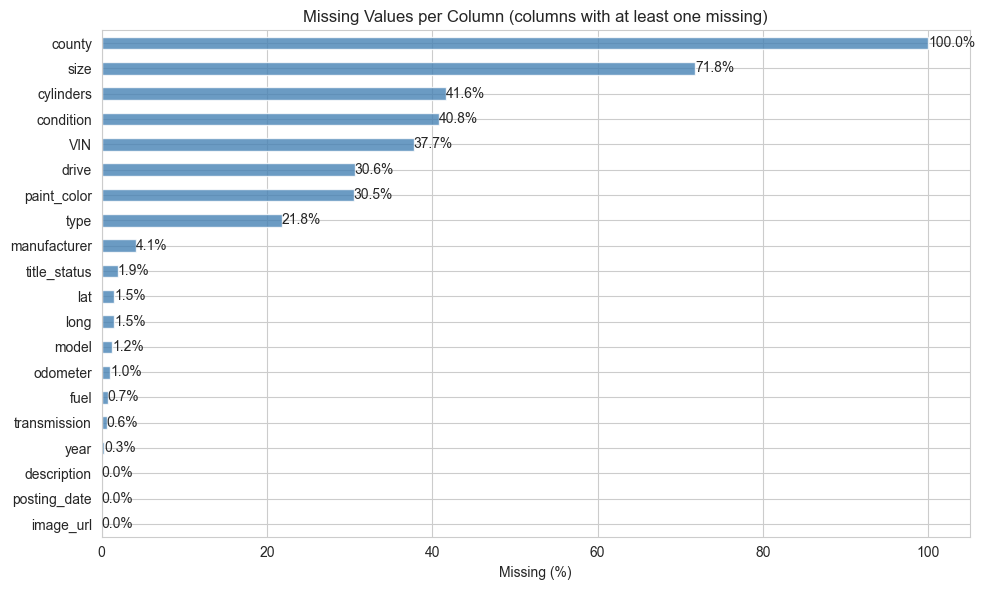

In [11]:
# 1.3 — Dataset Overview
print("=== .info() ===")
df.info()

print("\n=== .describe() (numerical) ===")
display(df.describe())

# Unique value counts per column (high-cardinality check)
unique_counts = df.nunique().sort_values(ascending=False)
print("\nUnique values per column (top 15):")
print(unique_counts.head(15))

# Missing values: percentage per column, sorted descending
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
missing_pct.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8);
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values per Column (columns with at least one missing)")
ax.invert_yaxis()
# Show percentage value on each bar
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.tight_layout()
plt.show()

## 1.4 — Target Variable Analysis (Price)

- Plot the raw price distribution (histogram + KDE).
- Identify extreme outliers: listings at $0–$1 and $999,999+ are likely spam.
- Apply percentile-based filtering (1st and 99th percentiles) to remove these.
- Re-plot the filtered price distribution and log-transformed distribution.
- Report basic statistics (mean, median, std) before and after filtering.

In [ ]:
# 1.4 — Target Variable Analysis (Price)

# --- Stats BEFORE filtering ---
print("=== Before filtering ===")
print(f"  Mean:   ${df['price'].mean():,.0f}")
print(f"  Median: ${df['price'].median():,.0f}")
print(f"  Std:    ${df['price'].std():,.0f}")
print(f"  Rows:   {len(df):,}")

# Raw price histogram (full range, including outliers)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["price"].dropna(), bins=100, color="steelblue", edgecolor="white");
ax.set_xlabel("Price ($)")
ax.set_ylabel("Count")
ax.set_title("Raw Price Distribution (full range — includes outliers)")
plt.tight_layout()
plt.show()

# Filter by 1st and 99th percentiles
p01 = df["price"].quantile(0.01)
p99 = df["price"].quantile(0.99)
print(f"\n1st percentile: ${p01:,.0f}")
print(f"99th percentile: ${p99:,.0f}")

# df_preview is for visualization only — actual filtering happens in 02_preprocessing.ipynb
df_preview = df[(df["price"] >= p01) & (df["price"] <= p99)].copy()

# --- Stats AFTER filtering ---
print("\n=== After filtering ===")
print(f"  Mean:   ${df_preview['price'].mean():,.0f}")
print(f"  Median: ${df_preview['price'].median():,.0f}")
print(f"  Std:    ${df_preview['price'].std():,.0f}")
print(f"  Rows:   {len(df_preview):,}  (removed {len(df) - len(df_preview):,})")

# Cleaned price histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_preview["price"], bins=80, color="steelblue", edgecolor="white");
ax.set_xlabel("Price ($)")
ax.set_ylabel("Count")
ax.set_title("Cleaned Price Distribution (1st–99th percentile)")
plt.tight_layout()
plt.show()

## 1.5 — Numerical Feature Distributions

For key numerical features (`year`, `odometer`):
- Plot histograms to see their distributions.
- Create scatter plots against `price` to visualize non-linear depreciation trends.
- Compute and display a correlation matrix / heatmap for all numerical columns.

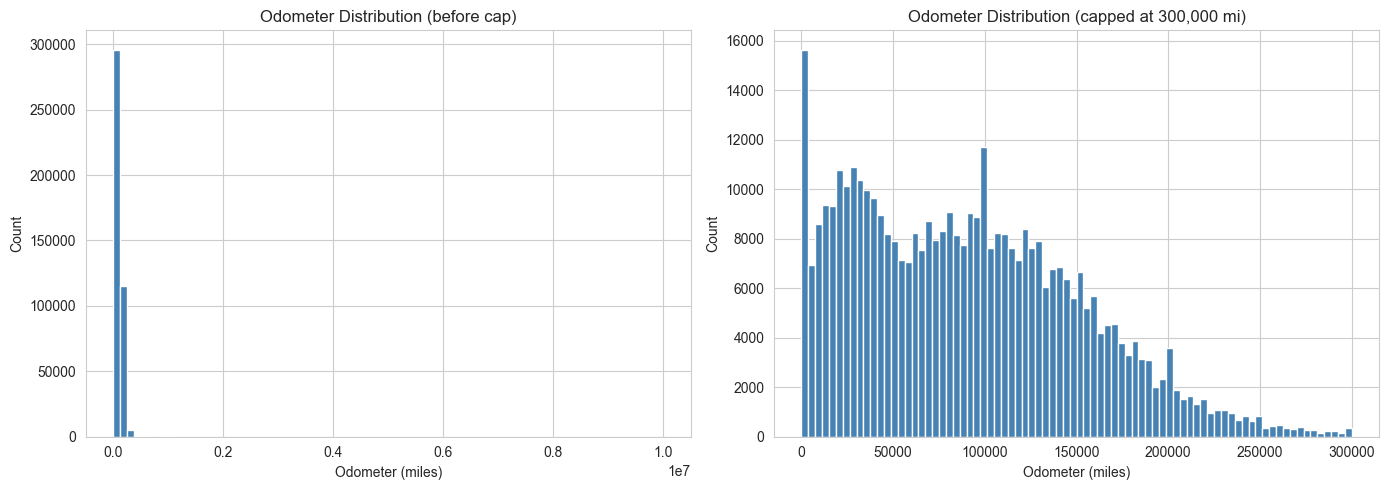

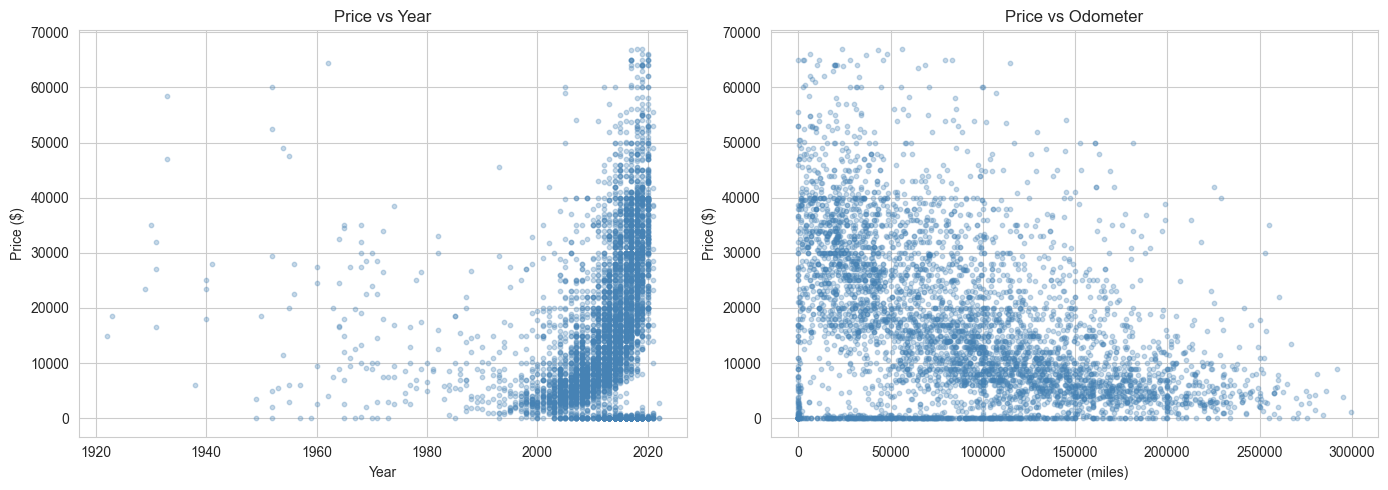

In [13]:
# 1.5 — Numerical Feature Distributions
# df_preview is for visualization only — actual filtering happens in 02_preprocessing.ipynb

# --- Raw odometer histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_preview["odometer"].dropna(), bins=80, color="steelblue", edgecolor="white");
axes[0].set_xlabel("Odometer (miles)")
axes[0].set_ylabel("Count")
axes[0].set_title("Odometer Distribution (before cap)")

# Apply upper cap at 300,000 miles
ODO_CAP = 300_000
df_preview = df_preview[df_preview["odometer"].fillna(0) <= ODO_CAP].copy()

axes[1].hist(df_preview["odometer"].dropna(), bins=80, color="steelblue", edgecolor="white");
axes[1].set_xlabel("Odometer (miles)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Odometer Distribution (capped at {ODO_CAP:,} mi)")
plt.tight_layout()
plt.show()

# --- Scatter plots (sampled for speed) ---
sample = df_preview.dropna(subset=["year", "odometer", "price"]).sample(
    n=min(5000, len(df_preview)), random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample["year"], sample["price"], alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Price vs Year")

axes[1].scatter(sample["odometer"], sample["price"], alpha=0.3, s=10, color="steelblue")
axes[1].set_xlabel("Odometer (miles)")
axes[1].set_ylabel("Price ($)")
axes[1].set_title("Price vs Odometer")
plt.tight_layout()
plt.show()

## 1.6 — Categorical Feature Analysis

For key categorical features (`manufacturer`, `condition`, `fuel`, `title_status`, `transmission`, `drive`, `type`, `paint_color`, `state`):
- Bar charts showing value counts (top N for high-cardinality ones).
- Box plots of `price` grouped by each categorical feature to visualize how categories relate to price.
- Special focus on `manufacturer`: compare median prices across top manufacturers.

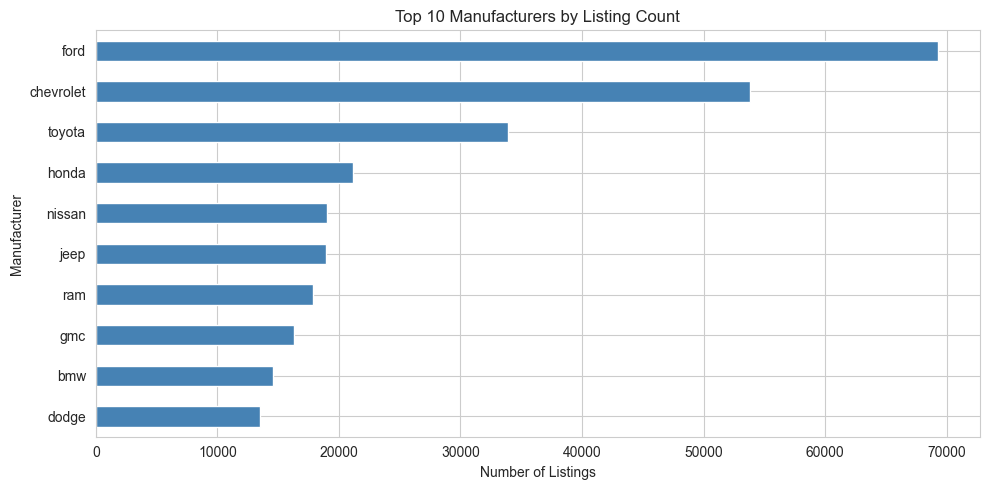

/var/folders/cn/5561qfrx0szdy0xwzv_9cn440000gn/T/ipykernel_13651/1055484315.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


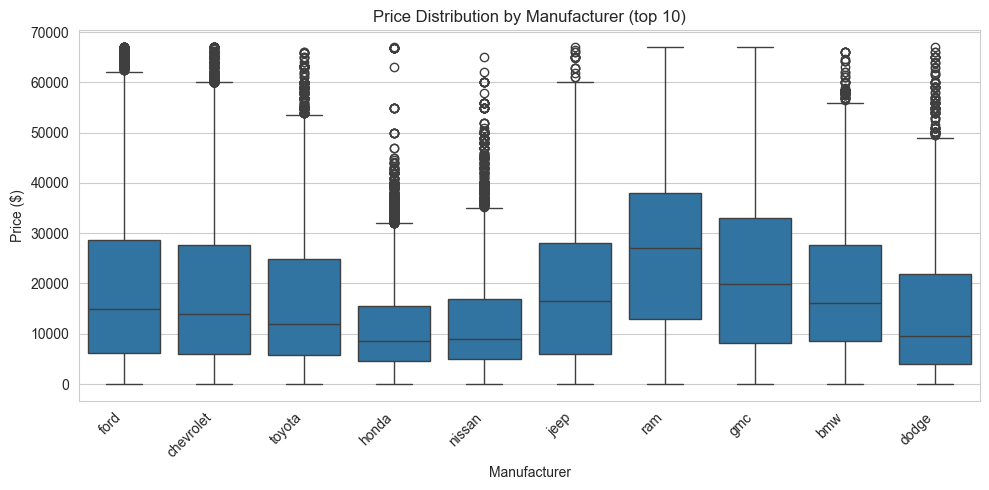

In [14]:
# 1.6 — Categorical Feature Analysis
# df_preview is for visualization only — actual filtering happens in 02_preprocessing.ipynb

# Top 10 manufacturers by listing count
top10 = df_preview["manufacturer"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind="barh", ax=ax, color="steelblue");
ax.set_xlabel("Number of Listings")
ax.set_ylabel("Manufacturer")
ax.set_title("Top 10 Manufacturers by Listing Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Box plot of price by manufacturer (top 10 only)
top10_names = top10.index.tolist()
df_top10 = df_preview[df_preview["manufacturer"].isin(top10_names)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_top10,
    x="manufacturer",
    y="price",
    order=top10_names,
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Manufacturer")
ax.set_ylabel("Price ($)")
ax.set_title("Price Distribution by Manufacturer (top 10)")
plt.tight_layout()
plt.show()

## 1.7 — Feature Interactions

- Explore how `year` × `odometer` interacts with price (e.g., scatter colored by manufacturer).
- Investigate brand-specific depreciation curves (price vs. year for top 5 manufacturers).
- Analyze how `condition` affects the price-odometer relationship.

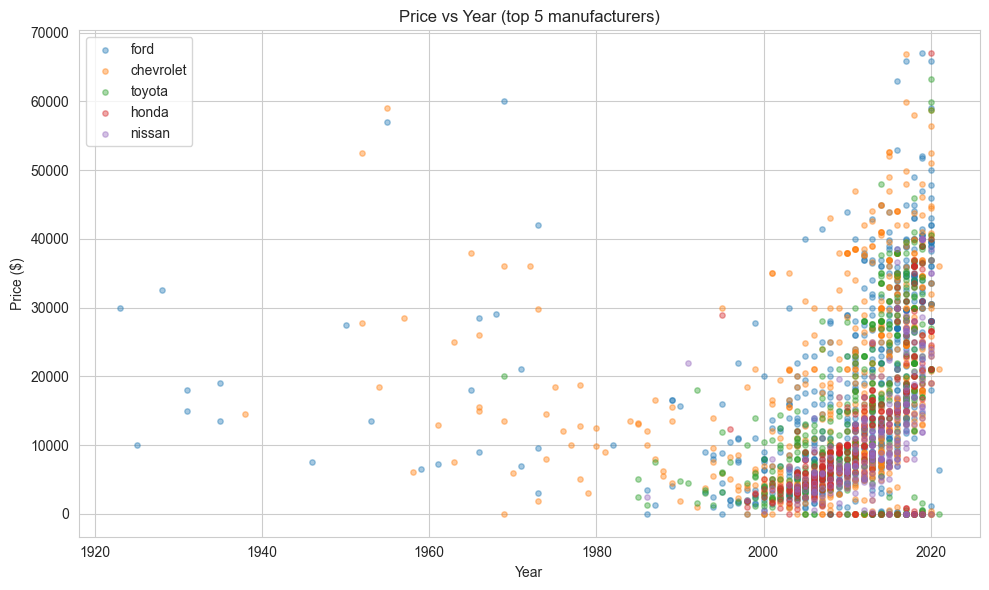

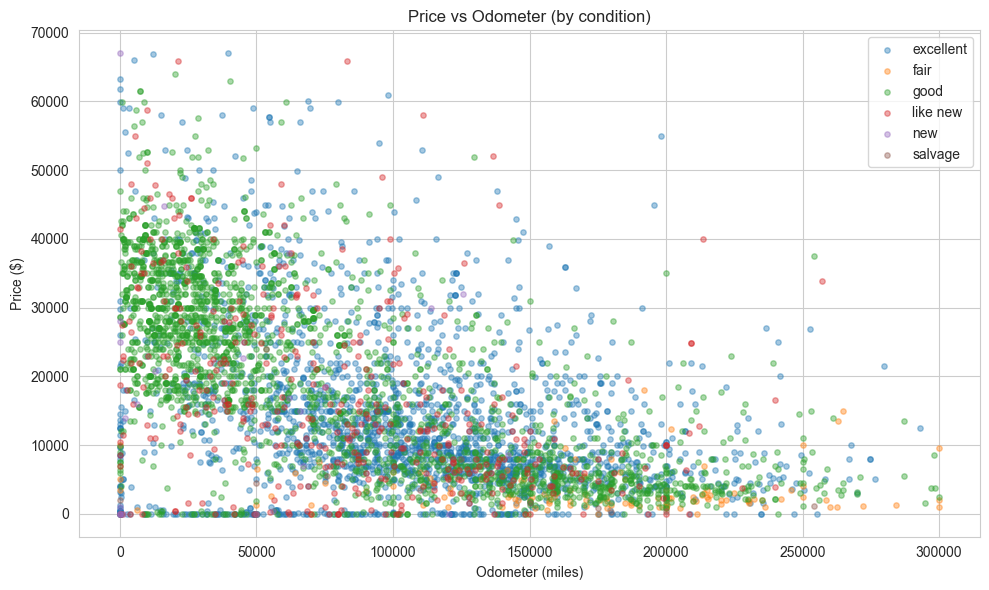

In [20]:
# 1.7 — Feature Interactions
# df_preview is for visualization only — actual filtering happens in 02_preprocessing.ipynb

sample = df_preview.dropna(subset=["year", "odometer", "price", "manufacturer", "condition"]).sample(
    n=min(5000, len(df_preview)), random_state=RANDOM_STATE
)

# --- Price vs Year colored by top 5 manufacturers ---
top5_mfr = df_preview["manufacturer"].value_counts().head(5).index.tolist()
sample_mfr = sample[sample["manufacturer"].isin(top5_mfr)]

fig, ax = plt.subplots(figsize=(10, 6))
for mfr in top5_mfr:
    sub = sample_mfr[sample_mfr["manufacturer"] == mfr]
    ax.scatter(sub["year"], sub["price"], alpha=0.4, s=15, label=mfr)
ax.set_xlabel("Year")
ax.set_ylabel("Price ($)")
ax.set_title("Price vs Year (top 5 manufacturers)")
ax.legend()
plt.tight_layout()
plt.show()

# --- Price vs Odometer colored by condition ---
fig, ax = plt.subplots(figsize=(10, 6))
conditions = sample["condition"].dropna().unique()
for cond in sorted(conditions):
    sub = sample[sample["condition"] == cond]
    ax.scatter(sub["odometer"], sub["price"], alpha=0.4, s=15, label=cond)
ax.set_xlabel("Odometer (miles)")
ax.set_ylabel("Price ($)")
ax.set_title("Price vs Odometer (by condition)")
ax.legend()
plt.tight_layout()
plt.show()

## 1.8 — Geographic Patterns

- Examine price distributions by `state` (top/bottom states by median price).
- Visualize regional pricing differences if meaningful patterns emerge.

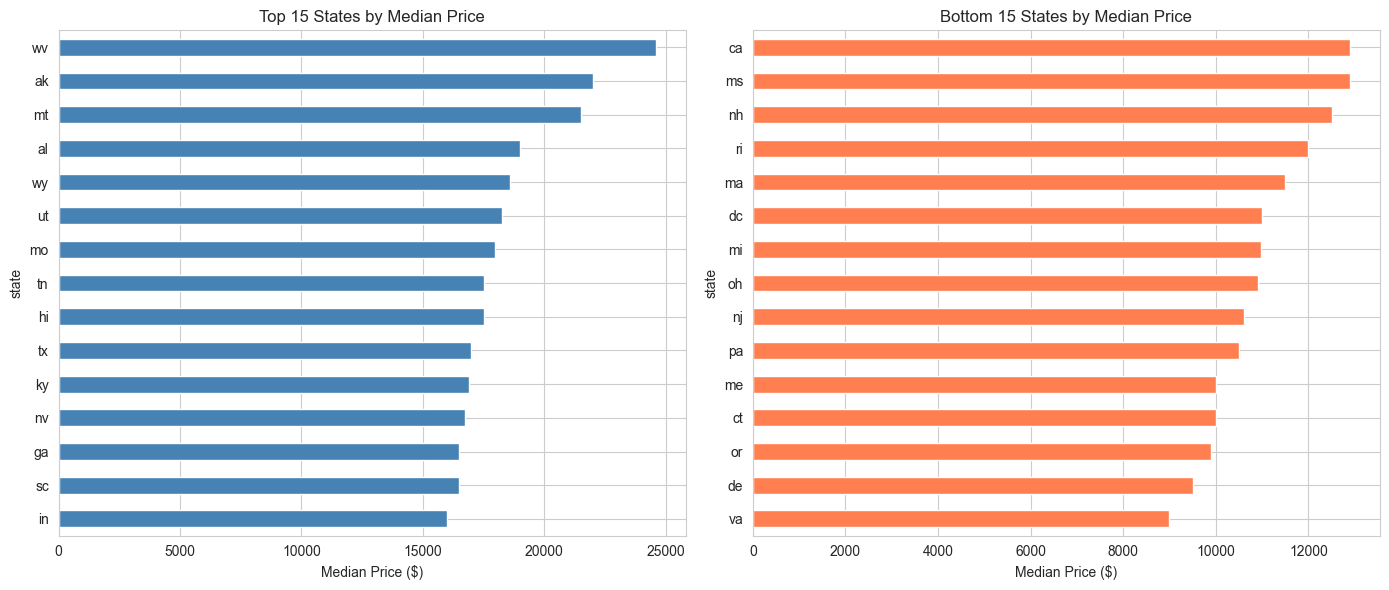

In [16]:
# 1.8 — Geographic Patterns
# df_preview is for visualization only — actual filtering happens in 02_preprocessing.ipynb

median_by_state = df_preview.groupby("state")["price"].median().sort_values()

# Top 15 most expensive states
top15 = median_by_state.tail(15)
# Bottom 15 cheapest states
bottom15 = median_by_state.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top15.plot(kind="barh", ax=axes[0], color="steelblue");
axes[0].set_xlabel("Median Price ($)")
axes[0].set_title("Top 15 States by Median Price")

bottom15.plot(kind="barh", ax=axes[1], color="coral");
axes[1].set_xlabel("Median Price ($)")
axes[1].set_title("Bottom 15 States by Median Price")

plt.tight_layout()
plt.show()

## 1.9 — Key Findings & Decisions for Preprocessing

Summarize the EDA findings that will drive preprocessing decisions:
- Which outlier thresholds to use.
- Which columns have too many missing values to keep.
- Which features appear most predictive.
- Which categorical features need Target Encoding vs. simpler encoding.
- Any features to drop entirely (e.g., `id`, `url`, `region_url`, `image_url`, `description`, `VIN`, `county`).

- Price filtered: $0 → $66,995 (removed 4,265 rows)
- Odometer capped at 300K miles
- Drop: county (100%), size (71.8%), id, url, VIN, description, image_url
- Target encode: model, state (high cardinality) [maybe we can cancel state]
- Ordinal encode: condition
- One-hot encode: fuel, transmission, drive, type
- Most predictive features appear to be: year, odometer, manufacturer